# Lab 1 — Data Preprocessing & Cleaning

In [ ]:
# Step 1: Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler
)
from sklearn.impute import SimpleImputer

print("All libraries imported successfully!")

In [ ]:
# Option A: Load from CSV file
df = pd.read_csv('your_dataset.csv')

In [5]:
# Step 2: Load dataset (using a sample CSV)
# You can replace this with your own dataset path

# Option A: Load from CSV file
## df = pd.read_csv('your_dataset.csv')

# Option B: Create a sample dataset for practice
data = {
    'Age':    [25, np.nan, 35, 42, np.nan, 52, 28, 38],
    'Salary': [50000, 60000, np.nan, 80000, 55000, np.nan, 72000, 90000],
    'Gender': ['Male', 'Female', 'Male', np.nan, 'Female', 'Male', 'Female', 'Male'],
    'City':   ['Delhi', 'Mumbai', 'Delhi', 'Chennai', 'Mumbai', 'Delhi', np.nan, 'Chennai'],
    'Purchased': ['No', 'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No']
}
df = pd.DataFrame(data)

print("Dataset Shape:", df.shape)
print("First 5 rows:")
print(df.head())

Dataset Shape: (8, 5)
First 5 rows:
    Age   Salary  Gender     City Purchased
0  25.0  50000.0    Male    Delhi        No
1   NaN  60000.0  Female   Mumbai       Yes
2  35.0      NaN    Male    Delhi        No
3  42.0  80000.0     NaN  Chennai       Yes
4   NaN  55000.0  Female   Mumbai       Yes


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        6 non-null      float64
 1   Salary     6 non-null      float64
 2   Gender     7 non-null      object 
 3   City       7 non-null      object 
 4   Purchased  8 non-null      object 
dtypes: float64(2), object(3)
memory usage: 452.0+ bytes
=== Statistical Summary ===
             Age        Salary
count   6.000000      6.000000
mean   36.666667  67833.333333
std     9.791152  15497.311595
min    25.000000  50000.000000
25%    29.750000  56250.000000
50%    36.500000  66000.000000
75%    41.000000  78000.000000
max    52.000000  90000.000000
=== Missing Values ===
Age          2
Salary       2
Gender       1
City         1
Purchased    0
dtype: int64
=== Missing Value Percentage ===
Age          25.0
Salary       25.0
Gender       12.5
City         12.5
Purchased     0.0
d

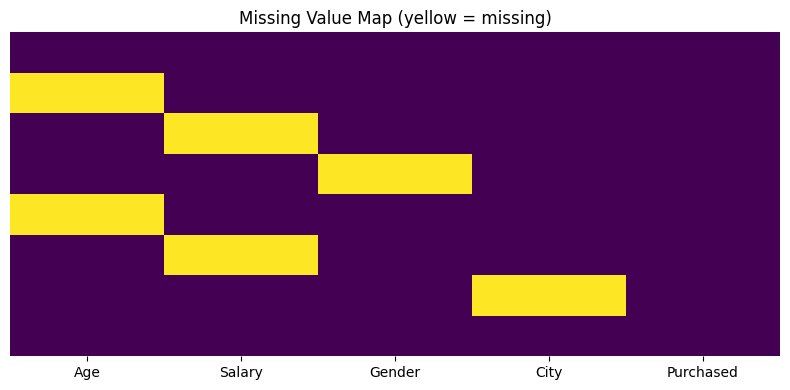

In [7]:
# Step 3: Exploratory analysis before cleaning

print("=== Dataset Info ===")
df.info()

print("=== Statistical Summary ===")
print(df.describe())

print("=== Missing Values ===")
print(df.isnull().sum())

print("=== Missing Value Percentage ===")
print((df.isnull().sum() / len(df)) * 100)

print("=== Data Types ===")
print(df.dtypes)

# Visualise missing values
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False,
            cmap='viridis', yticklabels=False)
plt.title('Missing Value Map (yellow = missing)')
plt.tight_layout()
plt.show()

In [8]:
# Step 4: Handle missing values

# --- Numerical columns: fill with mean ---
imputer_num = SimpleImputer(strategy='mean')
df['Age']    = imputer_num.fit_transform(df[['Age']])
df['Salary'] = imputer_num.fit_transform(df[['Salary']])

# --- Categorical columns: fill with most frequent value ---
imputer_cat = SimpleImputer(strategy='most_frequent')
df['Gender'] = imputer_cat.fit_transform(df[['Gender']]).ravel()
df['City']   = imputer_cat.fit_transform(df[['City']]).ravel()

print("Missing values after imputation:")
print(df.isnull().sum())
print("Dataset after handling missing values:")
print(df)

Missing values after imputation:
Age          0
Salary       0
Gender       0
City         0
Purchased    0
dtype: int64
Dataset after handling missing values:
         Age        Salary  Gender     City Purchased
0  25.000000  50000.000000    Male    Delhi        No
1  36.666667  60000.000000  Female   Mumbai       Yes
2  35.000000  67833.333333    Male    Delhi        No
3  42.000000  80000.000000    Male  Chennai       Yes
4  36.666667  55000.000000  Female   Mumbai       Yes
5  52.000000  67833.333333    Male    Delhi        No
6  28.000000  72000.000000  Female    Delhi       Yes
7  38.000000  90000.000000    Male  Chennai        No


Duplicates before: 0
Duplicates after:  0
Age: removed 1 outlier(s)
Salary: removed 0 outlier(s)


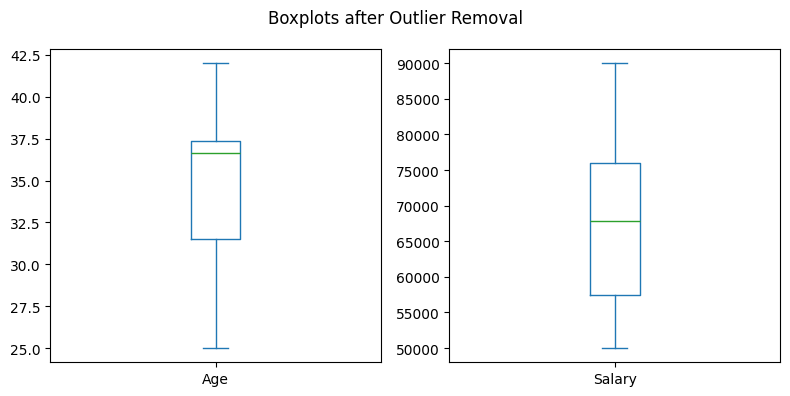

In [17]:
# Step 5: Remove duplicates and handle outliers

# --- Duplicates ---
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates after: ", df.duplicated().sum())

# --- Outlier detection using IQR method ---
def remove_outliers_iqr(df, col):
    Q1     = df[col].quantile(0.25)   # 25th percentile
    Q3     = df[col].quantile(0.75)   # 75th percentile
    IQR    = Q3 - Q1                  # interquartile range
    lower  = Q1 - 1.5 * IQR          # lower boundary
    upper  = Q3 + 1.5 * IQR          # upper boundary
    before = len(df)
    df = df[(df[col] >= lower) & (df[col] <= upper)]   # 4 spaces
    print(f"{col}: removed {before - len(df)} outlier(s)")
    return df

df = remove_outliers_iqr(df, 'Age')
df = remove_outliers_iqr(df, 'Salary')

# Boxplot to visualise
df[['Age', 'Salary']].plot(kind='box', subplots=True, figsize=(8, 4))
plt.suptitle('Boxplots after Outlier Removal')
plt.tight_layout()
plt.show()

In [19]:
# Step 6: Encode categorical variables

# --- Label Encoding for binary/ordinal column ---
le = LabelEncoder()
df['Purchased_encoded'] = le.fit_transform(df['Purchased'])

print("Label Encoding (Purchased):")
print(df[['Purchased', 'Purchased_encoded']].drop_duplicates())

# --- One-Hot Encoding for nominal column (City) ---
df = pd.get_dummies(df, columns=['City'], prefix='City')

# --- Label Encoding for Gender ---
df['Gender'] = le.fit_transform(df['Gender'])   # Male=1, Female=0

print("Dataset after Encoding:")
print(df.head())

Label Encoding (Purchased):
  Purchased  Purchased_encoded
0        No                  0
1       Yes                  1
Dataset after Encoding:
         Age        Salary  Gender Purchased  Purchased_encoded  City_Chennai  \
0  25.000000  50000.000000       1        No                  0         False   
1  36.666667  60000.000000       0       Yes                  1         False   
2  35.000000  67833.333333       1        No                  0         False   
3  42.000000  80000.000000       1       Yes                  1          True   
4  36.666667  55000.000000       0       Yes                  1         False   

   City_Delhi  City_Mumbai  
0        True        False  
1       False         True  
2        True        False  
3       False        False  
4       False         True  


After StandardScaler:
        Age    Salary
0 -1.727498 -1.361571
1  0.399321 -0.598073
2  0.095490  0.000000
3  1.371582  0.928922
4  0.399321 -0.979822
After MinMaxScaler:
        Age    Salary
0  0.000000  0.000000
1  0.686275  0.250000
2  0.588235  0.445833
3  1.000000  0.750000
4  0.686275  0.125000


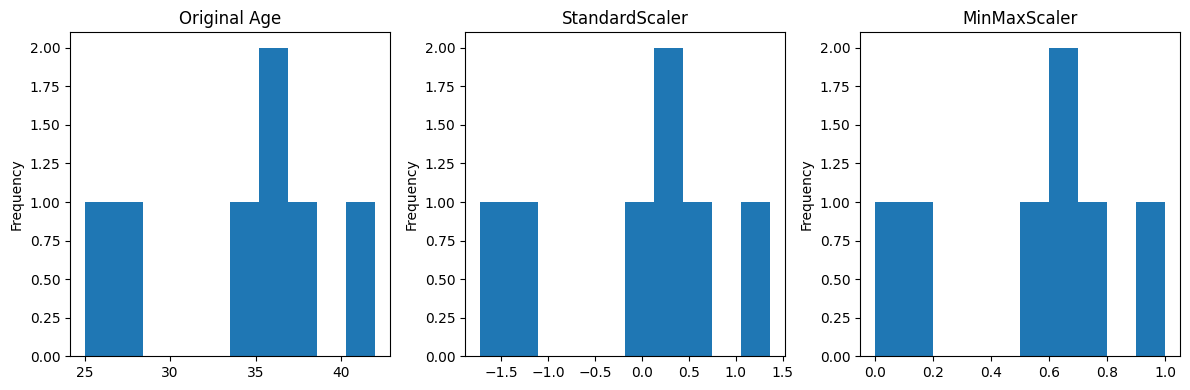

In [20]:
# Step 7: Feature scaling

# Separate features we want to scale
scale_cols = ['Age', 'Salary']

# --- Standardization (Z-score): mean=0, std=1 ---
scaler_std = StandardScaler()
df_std = df.copy()
df_std[scale_cols] = scaler_std.fit_transform(df[scale_cols])
print("After StandardScaler:")
print(df_std[scale_cols].head())

# --- Normalisation (Min-Max): range [0, 1] ---
scaler_mm = MinMaxScaler()
df_mm = df.copy()
df_mm[scale_cols] = scaler_mm.fit_transform(df[scale_cols])
print("After MinMaxScaler:")
print(df_mm[scale_cols].head())

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
df['Age'].plot(kind='hist', ax=axes[0], title='Original Age')
df_std['Age'].plot(kind='hist', ax=axes[1], title='StandardScaler')
df_mm['Age'].plot(kind='hist', ax=axes[2], title='MinMaxScaler')
plt.tight_layout()
plt.show()

In [21]:
# Step 8: Prepare final feature matrix X and target y

from sklearn.model_selection import train_test_split

# Drop original and redundant columns
df_final = df.drop(columns=['Purchased'])

X = df_final.drop(columns=['Purchased_encoded'])
y = df_final['Purchased_encoded']

# Apply scaling to final X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test  shape:", y_test.shape)
print("Preprocessing complete! Data is ready for modelling.")

X_train shape: (5, 6)
X_test  shape: (2, 6)
y_train shape: (5,)
y_test  shape: (2,)
Preprocessing complete! Data is ready for modelling.
